In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Raw data from 21-Sept-2026 to 05-Oct-2026
Kia Piccanto. John Cesar

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Downloads\1EYC.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13002 entries, 0 to 13001
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  13002 non-null  str  
 1   Message  13002 non-null  str  
 2   Status   13002 non-null  str  
dtypes: str(3)
memory usage: 304.9 KB


In [3]:
print(raw_data.iloc[raw_data.shape[0]-1])

Created                              2026-10-05 15:09:51.082
Message    [{"Protocol":"0x2626","MessageType":"LocationI...
Status     0x262602005342B008672840627094900019012C1E0000...
Name: 13001, dtype: str


In [4]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
02    6708
01    3058
03    2996
09     143
04      89
11       8
Name: count, dtype: int64

In [5]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])

torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133]))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(int(torch_codes_0204.iloc[i,2][150:154],16))
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

torch_codes_0204_ordered=torch_codes_0204.sort_values('date',ascending=True)

print(torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','engine_load']])

       i_on  i_off                 io  odometer          date  ext_ps  speed  \
0        25    300                0b0  89396630  260921000204   12.71      0   
3        25    300                0b0  89396630  260921000704   12.65      0   
5        25    300                0b0  89396630  260921001205   12.67      0   
7        25    300                0b0  89396630  260921001705   12.72      0   
10       25    300  0b100000000000000  89396630  260921002145   14.30      0   
...     ...    ...                ...       ...           ...     ...    ...   
12991    25    300                0b0  89610465  261005144944   12.42      0   
12994    25    300                0b0  89610465  261005145444   12.41      0   
12996    25    300                0b0  89610465  261005145944   12.43      0   
12998    25    300                0b0  89610465  261005150444   12.41      0   
13001    25    300                0b0  89610465  261005150944   12.39      0   

       acc_fuel_c  rpm remain_fuel  gns

In [6]:
torch_codes_0204_ordered.info()

<class 'pandas.DataFrame'>
Index: 6797 entries, 0 to 13001
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      6797 non-null   str    
 1   Message      6797 non-null   str    
 2   Status       6797 non-null   str    
 3   Codes        6797 non-null   str    
 4   i_on         6797 non-null   int64  
 5   i_off        6797 non-null   int64  
 6   io           6797 non-null   str    
 7   odometer     6797 non-null   int64  
 8   date         6797 non-null   str    
 9   ext_ps       6797 non-null   float64
 10  speed        6797 non-null   int64  
 11  gnss         6797 non-null   int64  
 12  acc_fuel_c   6797 non-null   float64
 13  rpm          6797 non-null   int64  
 14  cool_temp    6797 non-null   int64  
 15  remain_fuel  6797 non-null   str    
 16  engine_load  6797 non-null   int64  
dtypes: float64(2), int64(8), str(7)
memory usage: 955.8 KB


In [7]:
df=torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]
df.info()

<class 'pandas.DataFrame'>
Index: 6797 entries, 0 to 13001
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         6797 non-null   int64  
 1   i_off        6797 non-null   int64  
 2   io           6797 non-null   str    
 3   odometer     6797 non-null   int64  
 4   date         6797 non-null   str    
 5   ext_ps       6797 non-null   float64
 6   speed        6797 non-null   int64  
 7   acc_fuel_c   6797 non-null   float64
 8   rpm          6797 non-null   int64  
 9   remain_fuel  6797 non-null   str    
 10  gnss         6797 non-null   int64  
 11  cool_temp    6797 non-null   int64  
 12  Status       6797 non-null   str    
 13  engine_load  6797 non-null   int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 796.5 KB


Odometer

89396630
89396630
89396630
89396630
89396630
89396630
89396630
89396630
89396630
89396630
89396637
89396637
89396637
89396637
89396637
89396637
89396637
89396637
89396650
89396650
89396706
89396706
89396827
89396827
89396839
89396839
89397111
89397111
89397149
89397149
89397164
89397164
89397200
89397200
89397243
89397243
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397000
89397002
89397002
89397004
89397004
89397004
89397004
89397004
89397004
89397020
89397020
89397036
89397036
89397084
89397084
89397178
89397178
89397209
89397209
89397314
89397314
89397331
89397331
89397426
89397426
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397432
89397486
89397486
89397554
89397554
89397638
89397638
89397638
89397638
89398000
89398000
89398002
8

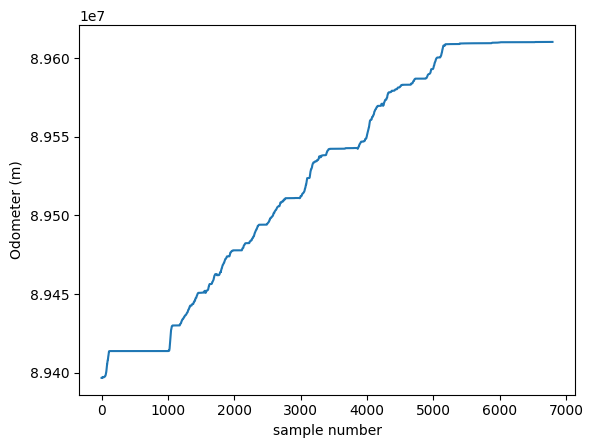

In [8]:
odometer=pd.DataFrame()
odometer_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    print(int(df.iloc[i,3]))
    #if int(df.iloc[i,3]>80000000):
    print(int(df.iloc[i,3]))
    status.append(df.iloc[i,12])
    odometer_data.append(int(df.iloc[i,3]))
    date.append(df.iloc[i,4])
    x_axis.append(i)
try:
    print(max(odometer_data),min(odometer_data))
except:
    print(df.iloc[i,3])

odometer['sample_number']=x_axis
odometer['odometer']=odometer_data
odometer['date']=date
odometer['status']=status

plt.ylabel("Odometer (m)")
plt.xlabel('sample number')
#plt.xticks(range(0,5572,100),rotation=90)
plt.plot(x_axis,odometer_data)

#odometer.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\odometer.csv')

Speed

94 0


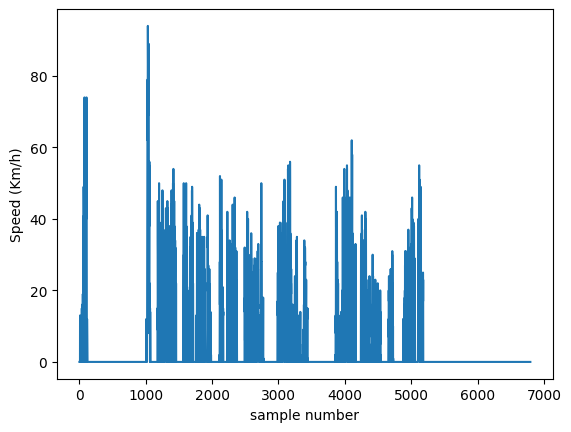

In [9]:
speed=pd.DataFrame()
speed_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):                        
        status.append(df.iloc[i,12])
        speed_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(speed_data),min(speed_data))
speed['sample_number']=x_axis
speed['speed']=speed_data
speed['status']=status

plt.ylabel("Speed (Km/h)")
plt.xlabel('sample number')
plt.plot(x_axis,speed_data)

#speed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\speed.csv')

RPM

3328 0


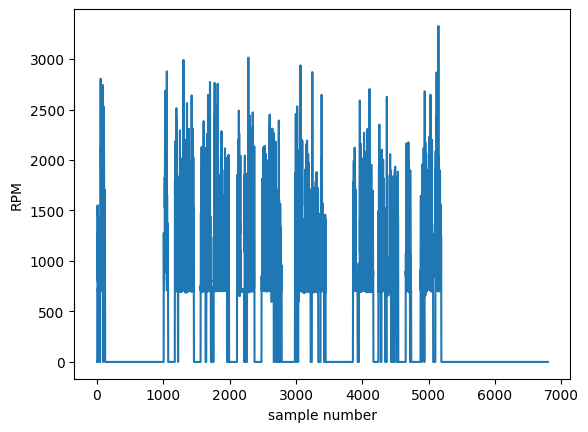

In [10]:
rpm=pd.DataFrame()
rpm_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
        if df.iloc[i,8]<65535:
                status.append(df.iloc[i,12])
                rpm_data.append(int(df.iloc[i,8]))
                date.append(df.iloc[i,4])
                x_axis.append(i)            

print(max(rpm_data),min(rpm_data))
rpm['sample_number']=x_axis
rpm['rpm']=rpm_data
rpm['status']=status

plt.ylabel("RPM")
plt.xlabel('sample number')
plt.plot(x_axis,rpm_data)
#rpm.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rpm.csv')

Fuel

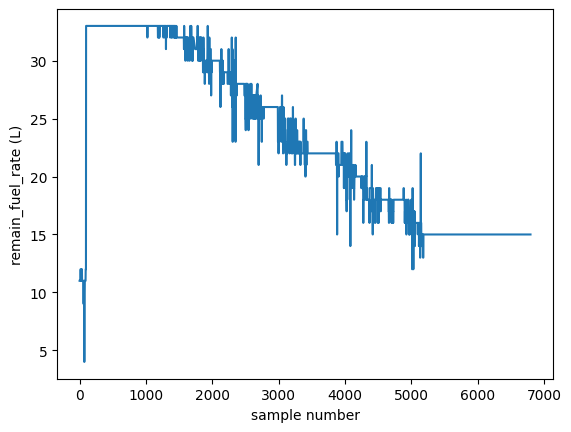

In [11]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

rfl['fuel_data']=fuel_data
rfl['date']=date
rfl['raw_data']=status
#rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl_1i1v.csv',sep=',')

Cooling fluid Temperature 

96 0


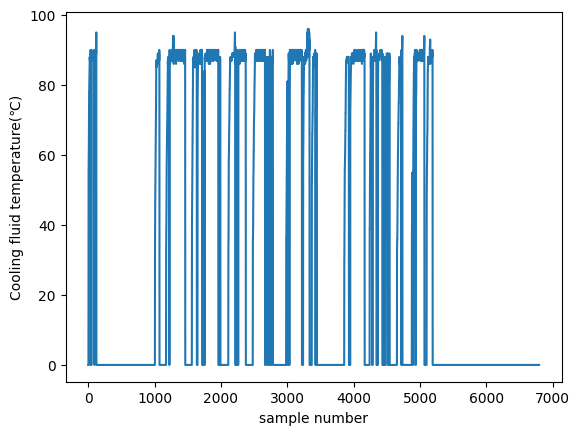

In [12]:
temp=pd.DataFrame()
temp_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
temp['sample_number']=x_axis
temp['date']=date
temp['temp']=temp_data
temp['status']=status

plt.ylabel("Cooling fluid temperature(℃)")
plt.xlabel('sample number')
plt.plot(x_axis,temp_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\temp.csv')

Engine load

96 0


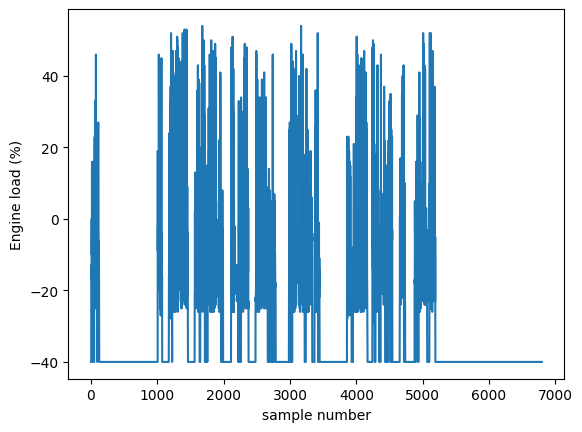

In [13]:
engine_load=pd.DataFrame()
engine_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
engine_load['sample_number']=x_axis
engine_load['date']=date
engine_load['engine load %']=engine_data
engine_load['status']=status

plt.ylabel("Engine load (%)")
plt.xlabel('sample number')
plt.plot(x_axis,engine_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\engine.csv')